# Latent Rectified Flow on MNIST

This notebook implements and trains a Latent Rectified Flow model that combines a VAE with Rectified Flow in latent space.

## Overview
- **Latent Rectified Flow**: Rectified Flow operating in VAE latent space
- **Efficiency**: Significantly faster than pixel-space due to lower dimensionality
- **Two-stage**: Pre-trained VAE + Rectified Flow in latent space
- **Training**: Minimize E[||v(z_t, t) - (z_1 - z_0)||²] in latent space
- **Sampling**: ODE integration in latent space → decode to images
- **Dataset**: MNIST (28x28 grayscale images)
- **Evaluation**: Compare with LDM (Latent Diffusion Model)

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
sys.path.append('..')

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, LearningRateMonitor
import matplotlib.pyplot as plt
import numpy as np
import time
import glob

from rectified_flow import LatentRectifiedFlow
from rectified_flow.callbacks import RFSamplingCallback, FlowProgressCallback
from vae.model import VariationalAutoencoder
from ldm import LatentDiffusionModel

# Set random seed for reproducibility
pl.seed_everything(42)

Seed set to 42


42

## 1. Data Loading

In [8]:
# Transform: normalize to [-1, 1] range
transform = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize((0.5,), (0.5,))
])

# Load MNIST
train_dataset = torchvision.datasets.MNIST(
    root='../data',
    train=True,
    download=True,
    transform=transform
)

val_dataset = torchvision.datasets.MNIST(
    root='../data',
    train=False,
    download=True,
    transform=transform
)

# Create dataloaders
batch_size = 128
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batch size: {batch_size}")

Training samples: 60000
Validation samples: 10000
Batch size: 128


## 2. Load Pre-trained VAE

First, we need a pre-trained VAE to encode images into latent space.

Loading VAE from: ../lightning_logs/vae_quick/version_0/checkpoints/best.ckpt


VAE latent dimension: 128
VAE reconstruction works: (8, 1, 28, 28)


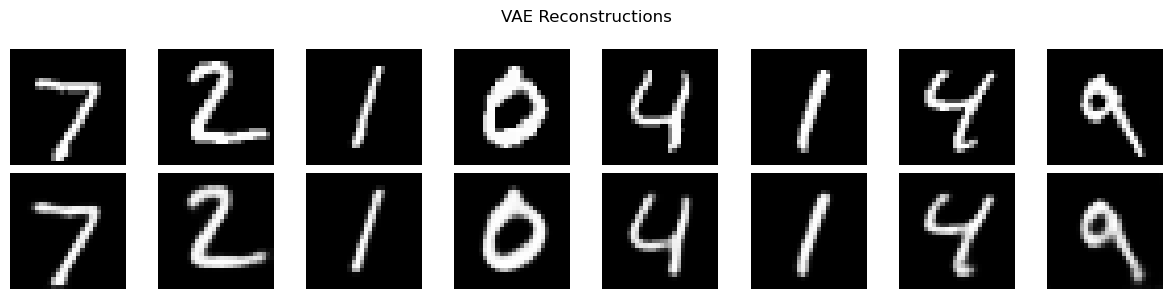

In [9]:
# Find VAE checkpoint
vae_checkpoints = glob.glob('../lightning_logs/vae_quick/version_0/checkpoints/best.ckpt')

if not vae_checkpoints:
    print("No VAE checkpoint found!")
    print("Please train a VAE first using notebooks/vae_mnist.ipynb")
    raise FileNotFoundError("VAE checkpoint not found")

vae_checkpoint = sorted(vae_checkpoints)[-1]  # Get latest
print(f"Loading VAE from: {vae_checkpoint}")

vae = VariationalAutoencoder.load_from_checkpoint(vae_checkpoint)
vae.eval()

# Test VAE
test_batch = next(iter(val_loader))
test_images = test_batch[0][:8]

with torch.no_grad():
    mu, logvar = vae.encoder(test_images.to(vae.device))
    reconstructed = torch.sigmoid(vae.decoder(mu))
    reconstructed = reconstructed.cpu().numpy()

print(f"VAE latent dimension: {mu.shape[1]}")
print(f"VAE reconstruction works: {reconstructed.shape}")

# Visualize VAE reconstructions
fig, axes = plt.subplots(2, 8, figsize=(12, 3))
for i in range(8):
    # Original
    axes[0, i].imshow(((test_images[i] + 1) / 2).squeeze(), cmap='gray')
    axes[0, i].axis('off')
    # Reconstructed
    axes[1, i].imshow(reconstructed[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=10)
axes[1, 0].set_ylabel('VAE Recon', fontsize=10)
plt.suptitle('VAE Reconstructions', fontsize=12)
plt.tight_layout()
plt.show()

## 3. Model Configuration

Configure Latent Rectified Flow to operate in the VAE's latent space.

In [10]:
# Get latent dimension from VAE
latent_dim = vae.hparams.latent_dim
print(f"Latent dimension: {latent_dim}")

# Create Latent Rectified Flow model
model = LatentRectifiedFlow(
    vae_model=vae,
    latent_dim=latent_dim,
    model_channels=64,
    channel_mult=(1, 2, 4),
    num_res_blocks=2,
    num_timesteps=1000,
    lr=2e-4,
    num_inference_steps=50,
    freeze_vae=True,  # Freeze VAE during training
    dropout=0.1,
    num_heads=4
)

# Count parameters
total_params = sum(p.numel() for p in model.parameters()) / 1e6
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad) / 1e6

print(f"Total parameters: {total_params:.2f}M")
print(f"Trainable parameters: {trainable_params:.2f}M (VAE frozen)")

Latent dimension: 128
Total parameters: 6.12M
Trainable parameters: 4.78M (VAE frozen)


## 4. Training Setup

In [11]:
# Callbacks
callbacks = [
    # Generate samples every 10 epochs
    RFSamplingCallback(
        num_samples=16,
        log_every_n_epochs=5,
        save_dir='../plots/latent_rectified_flow',
        num_steps=50
    ),
    
    # Visualize flow progress
    FlowProgressCallback(
        num_samples=8,
        num_steps_to_show=10,
        save_dir='../plots/latent_rectified_flow',
        log_at_epochs=[5, 10, 15, 20, 25, 30, 50, 100, 200]
    ),
    
    # Save best model
    ModelCheckpoint(
        dirpath='../data/saved_models/latent_rectified_flow',
        filename='lrf_mnist_{epoch:03d}_{val_loss:.4f}',
        monitor='val_loss',
        mode='min',
        save_top_k=3
    ),
    
    # Monitor learning rate
    LearningRateMonitor(logging_interval='epoch')
]

# Trainer
trainer = pl.Trainer(
    max_epochs=100,
    accelerator='gpu',
    devices=1,
    callbacks=callbacks,
    log_every_n_steps=50,
    gradient_clip_val=1.0,
    precision='16-mixed' if torch.cuda.is_available() else 32
)

print(f"Training device: {trainer.accelerator}")
print(f"Number of epochs: {trainer.max_epochs}")

Using 16bit Automatic Mixed Precision (AMP)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Training device: <pytorch_lightning.accelerators.cuda.CUDAAccelerator object at 0x71a7d1313280>
Number of epochs: 100


## 5. Train Model

Train Latent Rectified Flow in the VAE's latent space.

In [12]:
# Train
trainer.fit(model, train_loader, val_loader)

You are using a CUDA device ('NVIDIA GeForce RTX 5090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/home/xgeoadmin/miniconda3/envs/cuda-ml/lib/python3.10/site-packages/pytorch_lightning/utilities/model_summary/model_summary.py:231: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.

  | Name  | Type                   | Params | Mode 
---------------------------------------------------------
0 | vae   | VariationalAutoencoder | 1.3 M  | eval 
1 | model | UNetLatent             | 4.8 M  | train
---------------------------------------------------------
4.8 M     Trainable params
1.3 M     Non-trainable params

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/home/xgeoadmin/miniconda3/envs/cuda-ml/lib/python3.10/site-packages/pytorch_lightning/loops/fit_loop.py:527: Found 26 module(s) in eval mode at the start of training. This may lead to unexpected behavior during training. If this is intentional, you can ignore this warning.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=100` reached.


## 6. Load Best Model and Generate Samples

In [13]:
# Load best checkpoint
best_model_path = trainer.checkpoint_callback.best_model_path
print(f"Loading best model from: {best_model_path}")
model = LatentRectifiedFlow.load_from_checkpoint(
    best_model_path,
    vae_model=vae  # Pass VAE model
)
model.eval()
model = model.to('cuda' if torch.cuda.is_available() else 'cpu')

Loading best model from: /home/xgeoadmin/Nazar/ucu-genai-cv-2025/data/saved_models/latent_rectified_flow/lrf_mnist_epoch=095_val_loss=0.9721.ckpt


## 7. Sample Quality at Different Step Counts

Generating with 10 steps (Euler)...
Generating with 10 steps (Heun)...
Generating with 25 steps (Euler)...
Generating with 25 steps (Heun)...
Generating with 50 steps (Euler)...
Generating with 50 steps (Heun)...
Generating with 100 steps (Euler)...
Generating with 100 steps (Heun)...


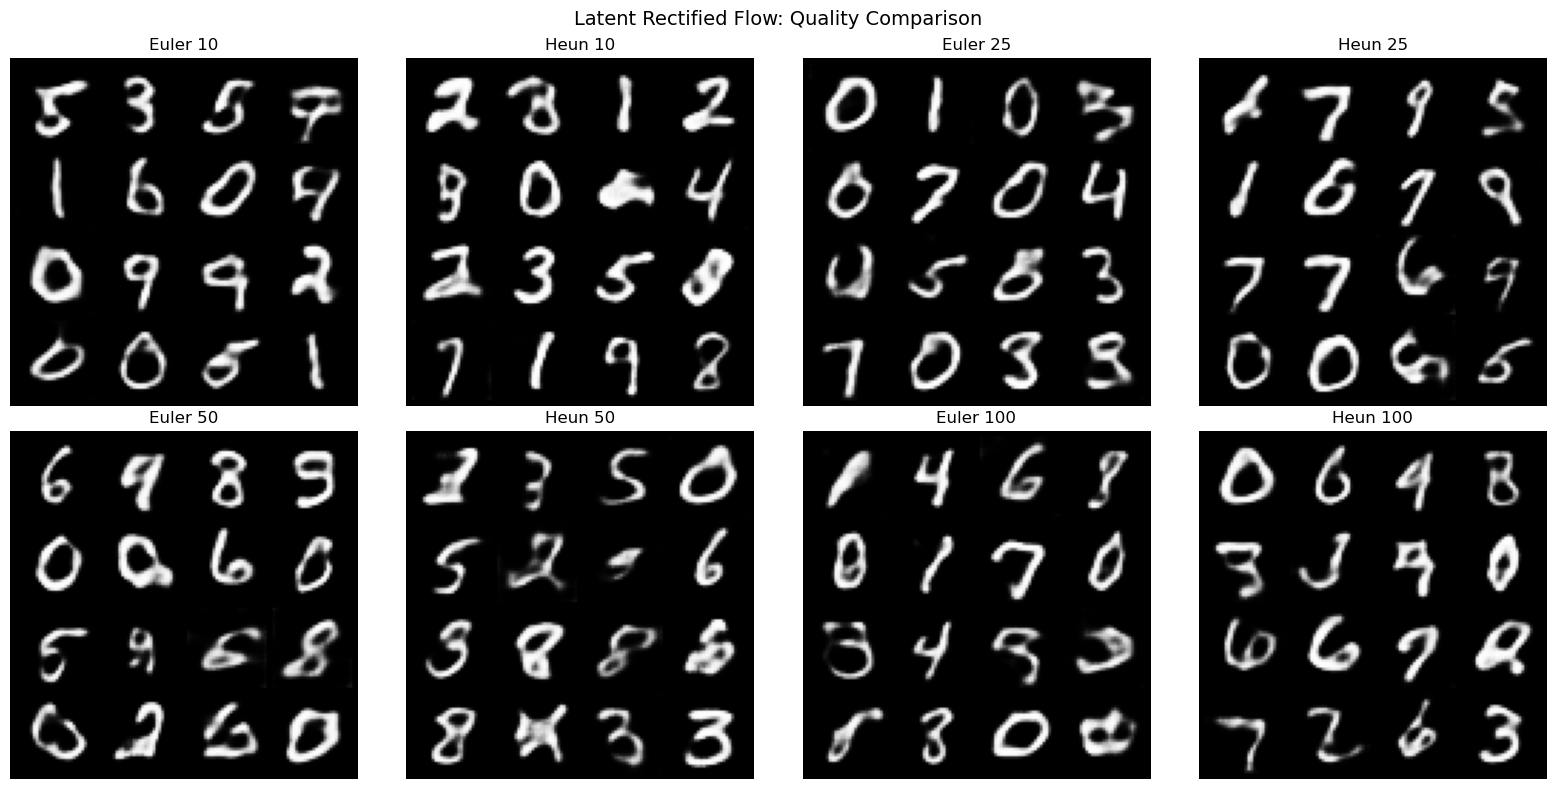

In [14]:
# Generate samples with different step counts
step_counts = [10, 25, 50, 100]
num_samples = 64

samples_dict = {}

for steps in step_counts:
    print(f"Generating with {steps} steps (Euler)...")
    with torch.no_grad():
        samples = model.sample(
            num_samples=num_samples,
            method='euler',
            num_inference_steps=steps
        )
    samples_dict[f'Euler {steps}'] = samples
    
    print(f"Generating with {steps} steps (Heun)...")
    with torch.no_grad():
        samples = model.sample(
            num_samples=num_samples,
            method='heun',
            num_inference_steps=steps
        )
    samples_dict[f'Heun {steps}'] = samples

# Plot
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, (name, samples) in enumerate(samples_dict.items()):
    grid = torchvision.utils.make_grid(
        samples[:16].cpu(), nrow=4, normalize=False
    )
    axes[idx].imshow(np.transpose(grid.numpy(), (1, 2, 0)), cmap='gray')
    axes[idx].set_title(name, fontsize=12)
    axes[idx].axis('off')

plt.suptitle('Latent Rectified Flow: Quality Comparison', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/latent_rectified_flow/lrf_quality_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Visualize Latent Flow Process

Generating latent flow visualization...


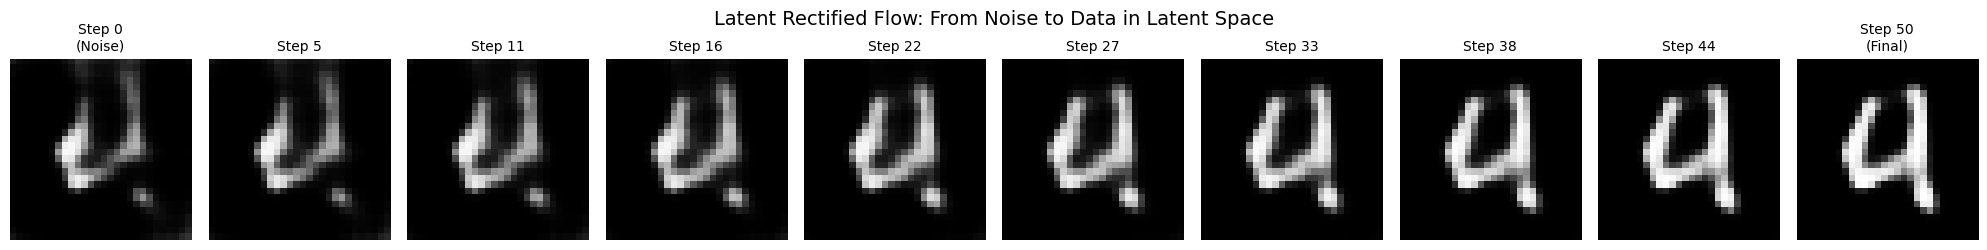

In [15]:
# Generate with all intermediate steps
print("Generating latent flow visualization...")
with torch.no_grad():
    final, all_steps, z_final, z_steps = model.sample(
        num_samples=1,
        method='euler',
        num_inference_steps=50,
        return_all_steps=True,
        return_latents=True
    )

# Select timesteps to show
num_steps_to_show = 10
indices = np.linspace(0, len(all_steps) - 1, num_steps_to_show, dtype=int)

fig, axes = plt.subplots(1, num_steps_to_show, figsize=(20, 2.5))

for i, idx in enumerate(indices):
    img = all_steps[idx][0].cpu()
    axes[i].imshow(img.squeeze(), cmap='gray', vmin=0, vmax=1)
    axes[i].axis('off')
    if i == 0:
        axes[i].set_title(f'Step {idx}\n(Noise)', fontsize=10)
    elif i == num_steps_to_show - 1:
        axes[i].set_title(f'Step {idx}\n(Final)', fontsize=10)
    else:
        axes[i].set_title(f'Step {idx}', fontsize=10)

plt.suptitle('Latent Rectified Flow: From Noise to Data in Latent Space', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/latent_rectified_flow/lrf_flow_process.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Speed Comparison: LRF vs LDM

Compare Latent Rectified Flow with Latent Diffusion Model.

Loading LDM from: ../lightning_logs/ldm_mnist/version_1/checkpoints/ldm-epoch=199-val_loss=0.0803.ckpt

Benchmarking LDM DDPM (1000 steps)...
Benchmarking LDM DDIM (50 steps)...
Benchmarking LRF Euler (50 steps)...
Benchmarking LRF Heun (50 steps)...


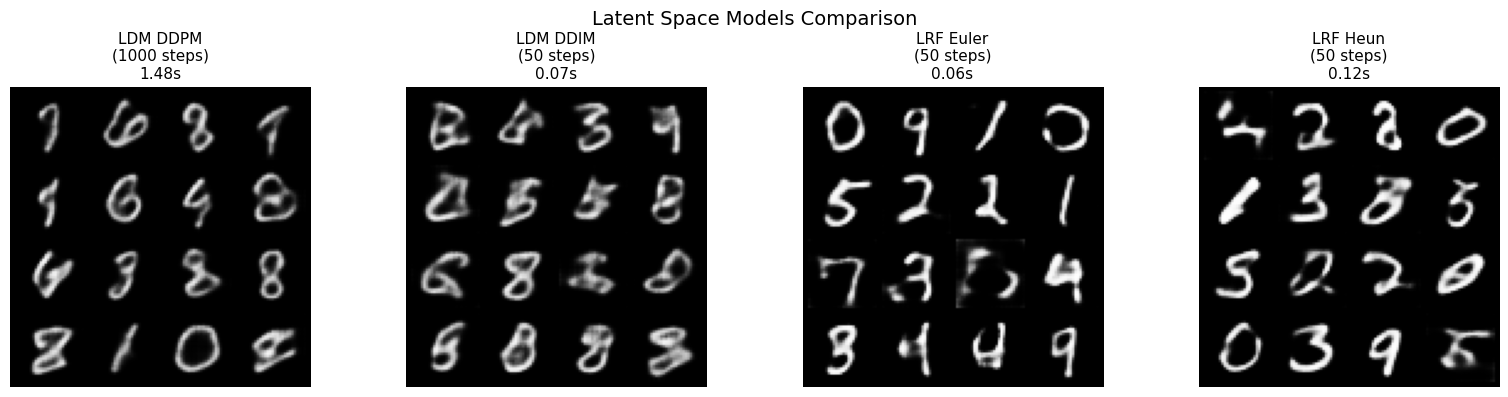


Speed Comparison (16 samples):
  LDM DDPM (1000 steps): 1.48s
  LDM DDIM (50 steps):   0.07s (21.84x faster)
  LRF Euler (50 steps):  0.06s (23.44x faster)
  LRF Heun (50 steps):   0.12s (11.85x faster)

LRF vs LDM DDIM speedup: 1.07x (Euler), 0.54x (Heun)


In [17]:
# Try to load LDM for comparison
ldm_checkpoints = glob.glob('../lightning_logs/ldm_mnist/version_1/checkpoints/*.ckpt')

if ldm_checkpoints:
    ldm_checkpoint = sorted(ldm_checkpoints)[-1]
    print(f"Loading LDM from: {ldm_checkpoint}")
    
    ldm_model = LatentDiffusionModel.load_from_checkpoint(
        ldm_checkpoint,
        vae_model=vae
    )
    ldm_model.eval()
    ldm_model = ldm_model.to('cuda' if torch.cuda.is_available() else 'cpu')
    
    num_samples_bench = 16
    
    # LDM DDPM
    print("\nBenchmarking LDM DDPM (1000 steps)...")
    start = time.time()
    with torch.no_grad():
        ldm_ddpm_samples = ldm_model.sample(num_samples=num_samples_bench, method='ddpm')
    ldm_ddpm_time = time.time() - start
    
    # LDM DDIM
    print("Benchmarking LDM DDIM (50 steps)...")
    start = time.time()
    with torch.no_grad():
        ldm_ddim_samples = ldm_model.sample(num_samples=num_samples_bench, method='ddim', num_inference_steps=50)
    ldm_ddim_time = time.time() - start
    
    # LRF Euler
    print("Benchmarking LRF Euler (50 steps)...")
    start = time.time()
    with torch.no_grad():
        lrf_euler_samples = model.sample(num_samples=num_samples_bench, method='euler', num_inference_steps=50)
    lrf_euler_time = time.time() - start
    
    # LRF Heun
    print("Benchmarking LRF Heun (50 steps)...")
    start = time.time()
    with torch.no_grad():
        lrf_heun_samples = model.sample(num_samples=num_samples_bench, method='heun', num_inference_steps=50)
    lrf_heun_time = time.time() - start
    
    # Visualize comparison
    fig, axes = plt.subplots(1, 4, figsize=(16, 4))
    
    methods = [
        ('LDM DDPM\n(1000 steps)', ldm_ddpm_samples, ldm_ddpm_time),
        ('LDM DDIM\n(50 steps)', ldm_ddim_samples, ldm_ddim_time),
        ('LRF Euler\n(50 steps)', lrf_euler_samples, lrf_euler_time),
        ('LRF Heun\n(50 steps)', lrf_heun_samples, lrf_heun_time)
    ]
    
    for idx, (name, samples, time_taken) in enumerate(methods):
        grid = torchvision.utils.make_grid(
            samples[:16].cpu(), nrow=4, normalize=False
        )
        axes[idx].imshow(np.transpose(grid.numpy(), (1, 2, 0)), cmap='gray')
        axes[idx].set_title(f'{name}\n{time_taken:.2f}s', fontsize=11)
        axes[idx].axis('off')
    
    plt.suptitle('Latent Space Models Comparison', fontsize=14)
    plt.tight_layout()
    plt.savefig('../plots/latent_rectified_flow/ldm_vs_lrf_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Speed summary
    print(f"\nSpeed Comparison ({num_samples_bench} samples):")
    print(f"  LDM DDPM (1000 steps): {ldm_ddpm_time:.2f}s")
    print(f"  LDM DDIM (50 steps):   {ldm_ddim_time:.2f}s ({ldm_ddpm_time/ldm_ddim_time:.2f}x faster)")
    print(f"  LRF Euler (50 steps):  {lrf_euler_time:.2f}s ({ldm_ddpm_time/lrf_euler_time:.2f}x faster)")
    print(f"  LRF Heun (50 steps):   {lrf_heun_time:.2f}s ({ldm_ddpm_time/lrf_heun_time:.2f}x faster)")
    print(f"\nLRF vs LDM DDIM speedup: {ldm_ddim_time/lrf_euler_time:.2f}x (Euler), {ldm_ddim_time/lrf_heun_time:.2f}x (Heun)")
    
else:
    print("No LDM checkpoint found. Train LDM first for comparison.")

## 10. Final Sample Grid

Generating final sample grid...


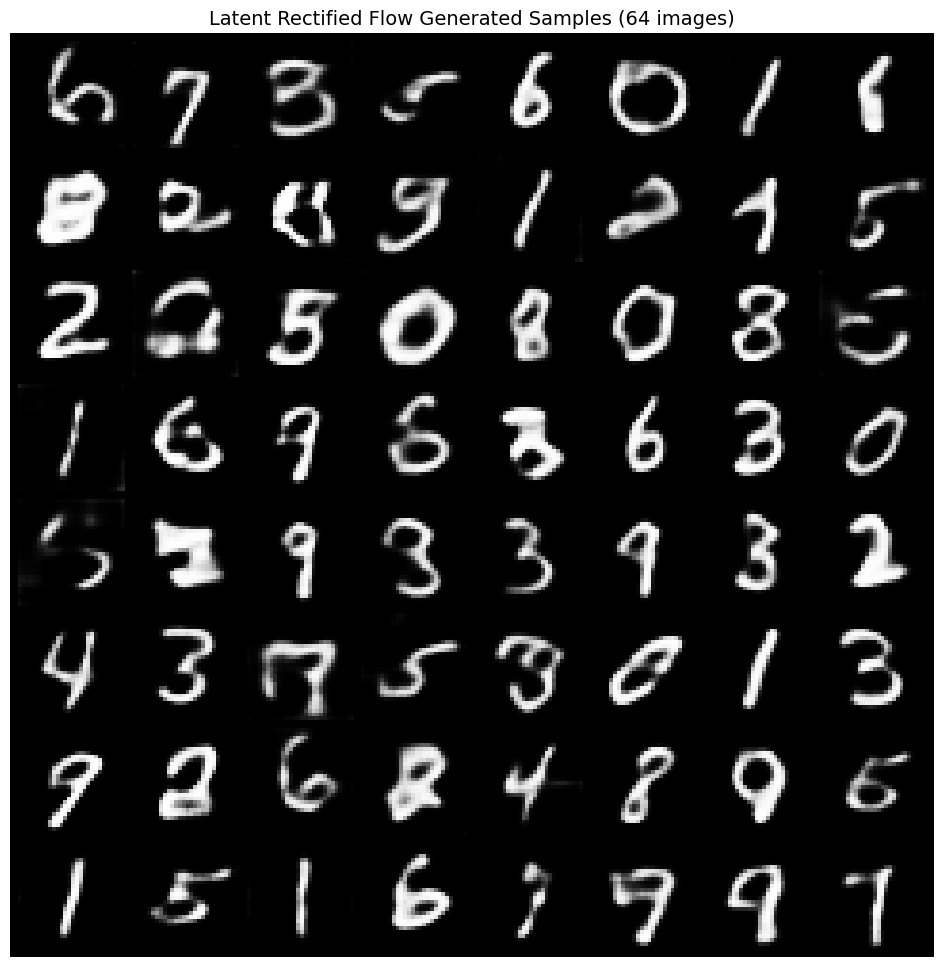

In [18]:
# Generate large batch of samples
print("Generating final sample grid...")
with torch.no_grad():
    final_samples = model.sample(
        num_samples=64,
        method='euler',
        num_inference_steps=50
    )

# Visualize
grid = torchvision.utils.make_grid(
    final_samples.cpu(), nrow=8, normalize=False
)

plt.figure(figsize=(12, 12))
plt.imshow(np.transpose(grid.numpy(), (1, 2, 0)), cmap='gray')
plt.title('Latent Rectified Flow Generated Samples (64 images)', fontsize=14)
plt.axis('off')
plt.savefig('../plots/latent_rectified_flow/lrf_final_samples.png', dpi=150, bbox_inches='tight')
plt.show()

## Summary

This notebook demonstrated:
1. **Latent Rectified Flow**: Combined VAE with Rectified Flow in latent space
2. **Efficiency**: Much faster than pixel-space due to lower dimensionality
3. **Quality**: Maintained generation quality while reducing computation
4. **Comparison**: Evaluated against Latent Diffusion Model (LDM)

**Key Findings**:
- Latent RF offers similar speedup to Latent Diffusion vs pixel-space
- Straight-line paths may offer training stability benefits
- Euler method provides good speed/quality tradeoff
- Heun method offers better accuracy for critical applications
- Competitive with LDM DDIM in terms of speed and quality